In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 15

# manifold.TSNE
from sklearn import manifold  #, datasets
from time import time

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import tensorflow as tf

# Load the data

In [2]:
fname,fnamey="x_3d.dat","y_3d.dat"
data=np.loadtxt(fname, delimiter='\t')
y=np.loadtxt(fnamey,dtype=int)
N=len(data)
D=len(data[0])
print("N=",N,"  D=",D)
x=data

N= 600   D= 3


# 1. Varying “random_state”

Different "random_state" values have been tested for a fixed perplexity value. 
With the increase in perplexity clusters develop more defined shapes, for this reason we chose to fix the perplexity to a quite high value.

Shape, size and distances between clusters are strongly affected by the initialization of the random state.

Different initializations lead to various topologies, sometimes artificial breaks might appear.
An evident example comes from the yellow cluster that may be composed of 2 parts or 1 depending on the random state. 

Moreover multiple runs can lead to visually very similar results up to symmetries.


/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/pytho

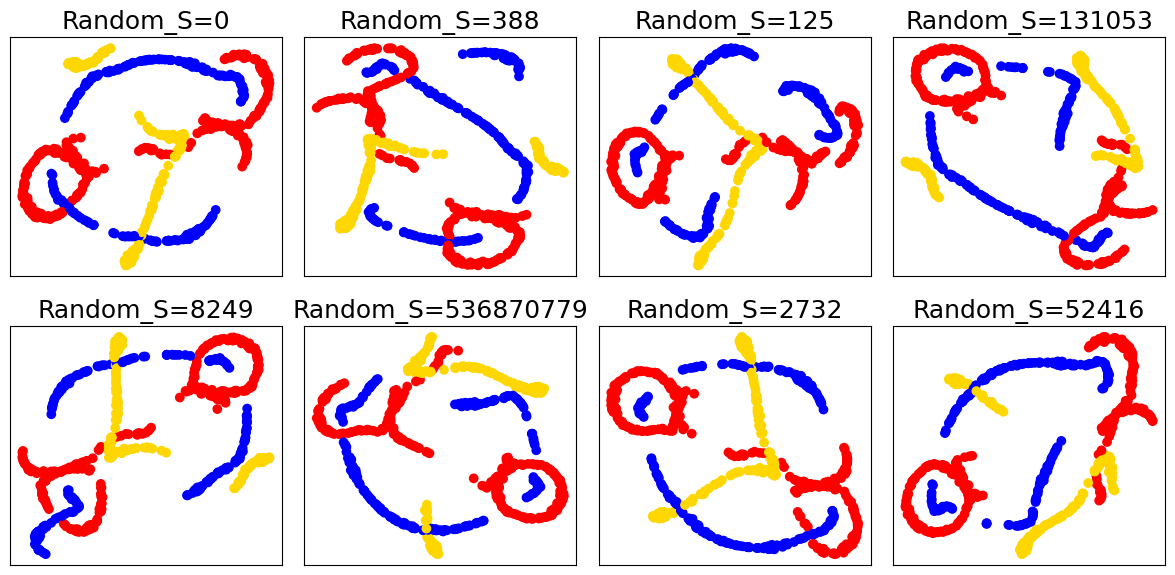

In [3]:
np.random.seed(0)
n_samples = N
n_components = 2 

perplexity = 100
random_state = [0,388,(2**7-3),(2**17-19),(2**13+57),(2**29-133),2732,52416]

Np = len(random_state)
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(2,4 , figsize=(12,6))

X_all = [None]
for i, random_state in enumerate(random_state):
    if(i<4):j=0
    else: j=1
    ax = subplots[j,i-4*j]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, init='random',
                         random_state=random_state, perplexity=perplexity)
    Y = tsne.fit_transform(data)
    t1 = time()
    ax.set_title("Random_S=%d" % random_state)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap)
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y)

fig.tight_layout()    
plt.show()

Also lower perplexities have been analysed for various random states.
The dependency on the initialization is even more evident in this case, in particular the change in topology is enhanced, as shown in the picture the blue cluster appears both as a circle or as one or two broken segments. 

As expected different initializations can also produce the same result up to rotations. 

/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/shared-libs/python3.9/py/lib/pytho

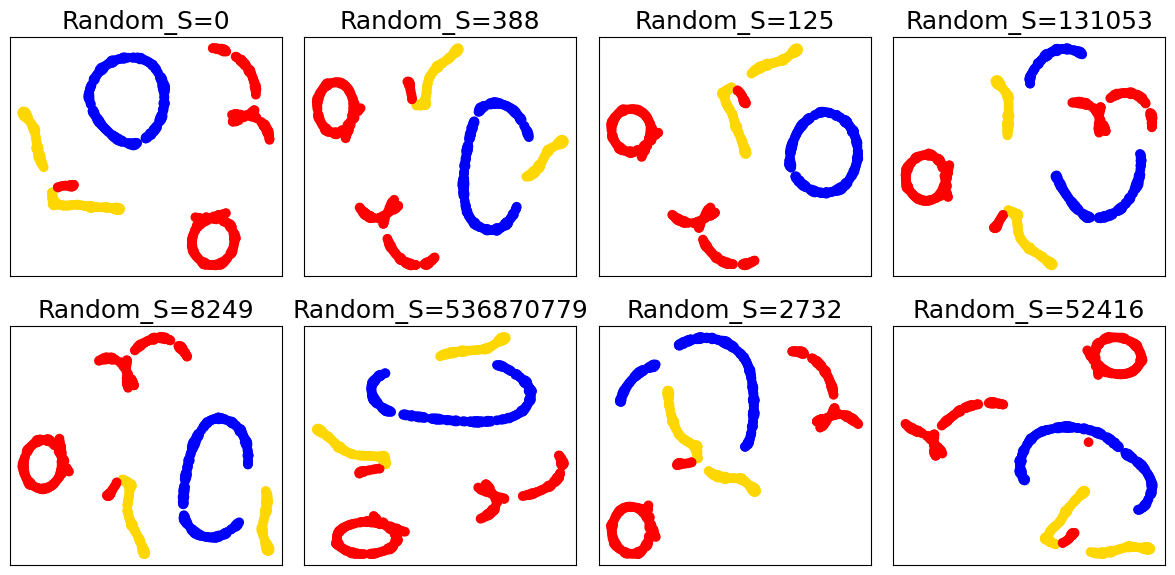

In [4]:
np.random.seed(0)
n_samples = N
n_components = 2

perplexity = 20
random_state = [0,388,(2**7-3),(2**17-19),(2**13+57),(2**29-133),2732,52416]

Np = len(random_state)
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(2,4 , figsize=(12,6))

X_all = [None]
for i, random_state in enumerate(random_state):
    if(i<4):j=0
    else: j=1
    ax = subplots[j,i-4*j]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, init='random',
                         random_state=random_state, perplexity=perplexity)
    Y = tsne.fit_transform(data)
    t1 = time()
    ax.set_title("Random_S=%d" % random_state)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap)
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y)

fig.tight_layout()    
plt.show()

# 2. DBSCAN algorithm

DBSCAN is a clustering algorithm that groups together points that are close to each other in a high-density region while marking outliers as noise. Its main parameters are "eps," representing the maximum distance between neighboring points, and "minPts," representing the minimum number of points required to form a cluster.

In [5]:
def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the entropy of a cluster
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true)
    c = clustering(y_pred)
    n_sample = len(y_true)

    Iwc = 0.
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc])))
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc])))
    Iwc/=n_sample
    Hc = entropy(c,n_sample)
    Hw = entropy(w,n_sample)

    return 2*Iwc/(Hc+Hw)

MinPts and epsilon (ε) are the parameters we will try to tune for DBSCAN clustering. MinPts should be at least 3 to avoid results similar to hierarchical clustering algorithm but larger values are better for noisy or large datasets. A suggested value to start from is between D and 2D, where D is the dimension of the dataset: this choice was made here. A good value for ε can be determined, supposedly, using a k-distance graph, where the value of ε is where an "elbow" is observed, a point of maximum slope, like illustrated [here](https://iopscience.iop.org/article/10.1088/1755-1315/31/1/012012/pdf).

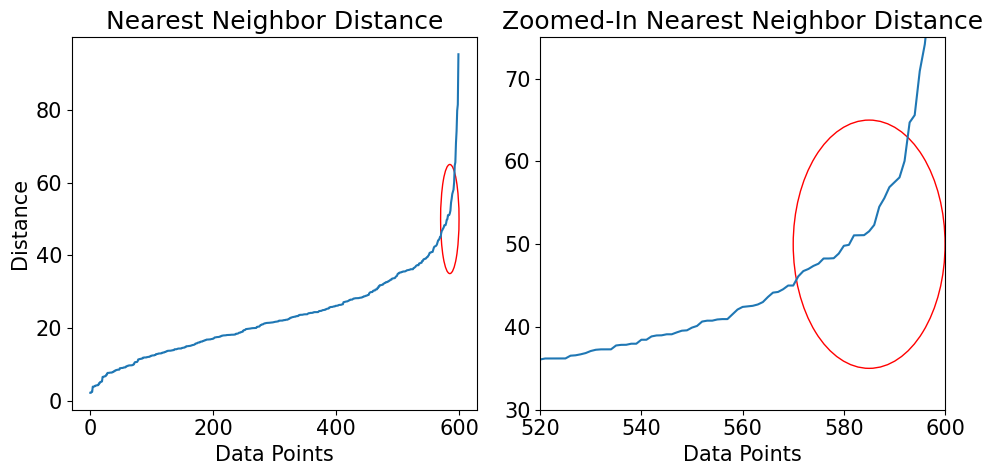

In [6]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=2*D)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)


distances = np.sort(distances, axis=0)
distances = distances[:,1]


fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(distances)
axs[0].set_title("Nearest Neighbor Distance")
axs[0].set_xlabel("Data Points")
axs[0].set_ylabel("Distance")

# zoom in 
axs[1].plot(distances)
axs[1].set_title("Zoomed-In Nearest Neighbor Distance")
axs[1].set_xlabel("Data Points")
axs[1].set_xlim([520, 600]) 
axs[1].set_ylim([30, 75])

px = 585
py = 50
r = 15
r0=35
circle = plt.Circle((px, py), r, color='r', fill=False)
circle0 = plt.Circle((px, py), r, color='r', fill=False)
axs[0].add_artist(circle0)
axs[1].add_artist(circle)

fig.tight_layout()
plt.show()

Unfortunately, the result of the "elbow" researched kneighboring distance is not a good candidate for ε as can be clearly seen from the heat-map below. On the other hand the assumption for D < MinPts < 2D seems to work reasonably well.  

In [8]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid
from collections import OrderedDict

X = data
y_true = y

eps_min = 70
eps_max = 200

min_samples_min = 1
min_samples_max = 50

param_grid = {'eps': np.arange(eps_min,eps_max), 'min_samples': np.arange(min_samples_min,min_samples_max)}

# generate all combinations of parameters
param_list = list(ParameterGrid(param_grid))

# loop over parameter grid
    
for params in param_list:
    dbscan = DBSCAN(**params)
    dbscan.fit(X)
    y_hat = dbscan.labels_
    params['nmi'] = NMI(y_hat, y_true)

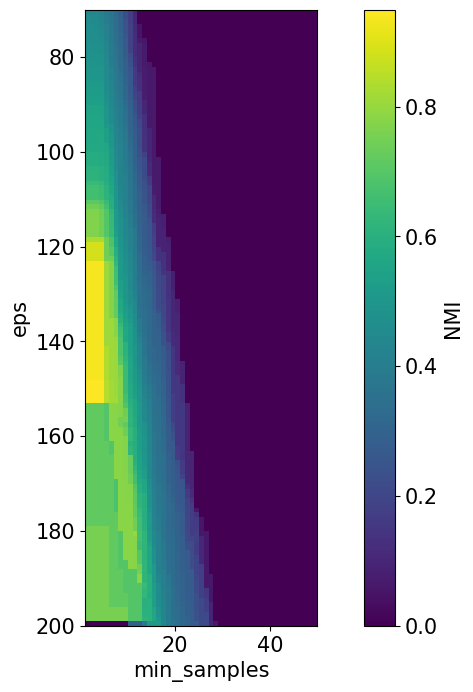

In [11]:
nx = min_samples_max - min_samples_min
ny = eps_max - eps_min

data = np.zeros((ny, nx))

# populate the numpy array with the coordinates
for params in param_list:
    data[ params['eps'] - eps_min, params['min_samples'] - min_samples_min] = params['nmi']

fig, ax = plt.subplots(figsize=(12, 8))

# create the heatmap using imshow()
pos = ax.imshow(data, interpolation='nearest', extent=[min_samples_min,min_samples_max,eps_max,eps_min])
fig.colorbar(pos, ax=ax, label='NMI')

# add labels to the x and y axes
plt.xlabel('min_samples')
plt.ylabel('eps')

# show the plot
plt.show()

From this graph we can see that the highest NMI values are obtained for low min\_samples values \(less than 10\) and epsilon values between 120 and 150\.

We can also see correlations between the parameters epsilon and min\_samples since in the left area of the graph we see decreasing curves with an approximately constant NMI ranging from the top left to the bottom right\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=53299e93-ff91-4e15-afd1-cdef99b4b328' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>